# Experiment with Liner model

In [1]:
import sys
import warnings
import math as m
import numpy as np
import pandas as pd
import tensorly as tl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.graph_objs as go

from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import acf

import scipy
from scipy.signal import find_peaks
from scipy.spatial import distance_matrix
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.nn.parameter import Parameter
from torch.nn.init import xavier_normal_, xavier_uniform_

sys.path.append('./../')
from tensordynamicmodel.visuals import plot_phase_trajectory, delay_embedding_matrix
from tensordynamicmodel.utils import delay_embedding_matrix, diag_mean, prepare_time_series, lorenz

In [2]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams.update({"text.usetex": False})

In [3]:
dt = 0.01
num_steps = 10000

xyzs = np.empty((num_steps + 1, 3))  # Need one more for the initial values
xyzs[0] = (0., .5, .55)  # Set initial values
# Step through "time", calculating the partial derivatives at the current point
# and using them to estimate the next point
for i in range(num_steps):
    xyzs[i + 1] = xyzs[i] + lorenz(xyzs[i]) * dt
# noize = np.random.randn(*xyzs.shape)*1.5
# xyzs += noize
    
ax = 40/180 * np.pi
ay = 0/180 * np.pi
az = 60/180 * np.pi

T_X = np.array([[1,0,0],
                [0,np.cos(ax),-np.sin(ax)],
                [0,np.sin(ax), np.cos(ax)]])

T_Y = np.array([[np.cos(ay),-np.sin(ay),0],
                [np.sin(ay), np.cos(ay),0],
                [0,0,1]])

T_Z = np.array([[ np.cos(az),0,np.sin(az)],
                [ 0,1,0],
                [-np.sin(az),0,np.cos(az)]])

xyzs = xyzs@T_Z@T_Y@T_X

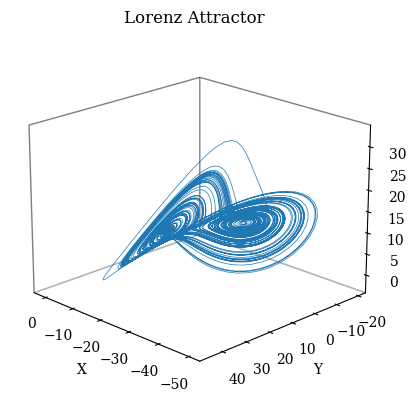

In [4]:
ax = plt.figure().add_subplot(projection='3d')

ax.plot(*xyzs.T, lw=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Lorenz Attractor")

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.view_init(elev=20, azim=135)

ax.grid(False)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
    
plt.savefig('./../figure/lorenz_attractor.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

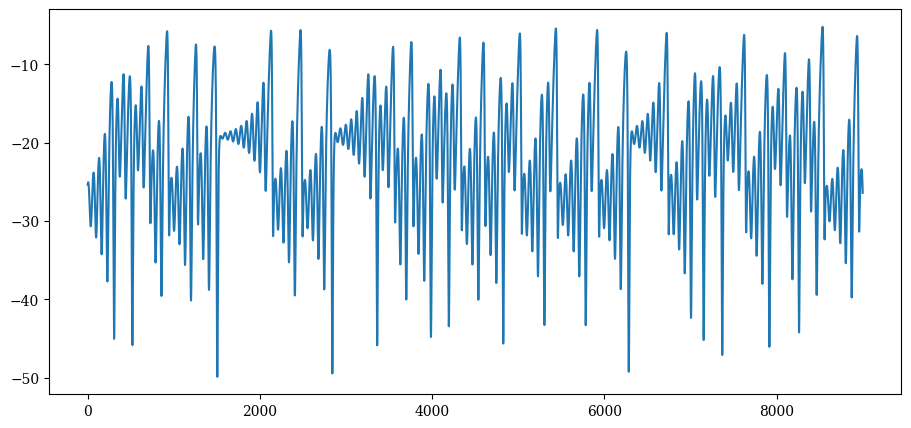

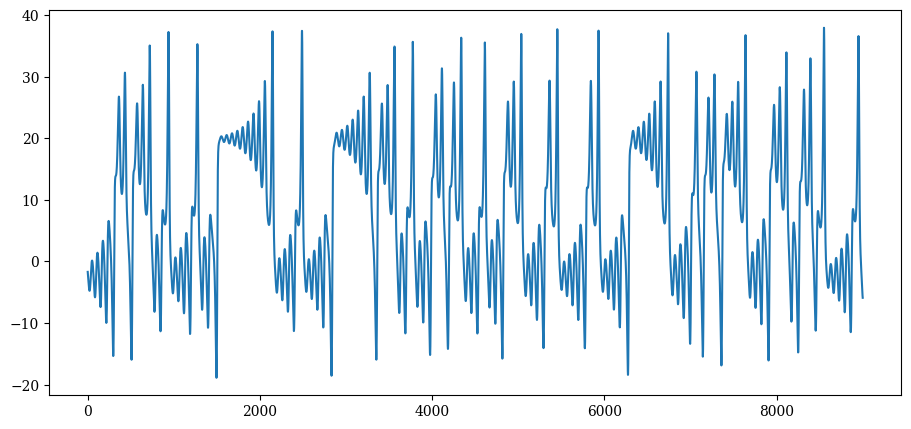

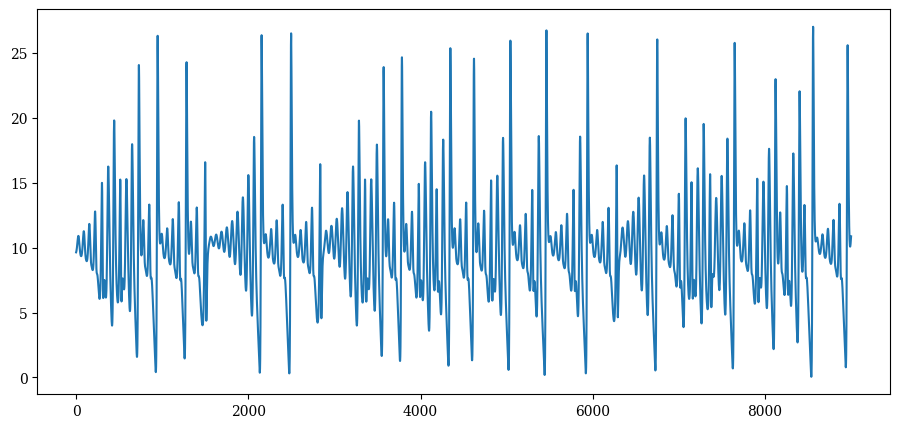

In [5]:
ax = plt.figure(figsize=(11,5)).add_subplot()
ax.plot(xyzs[1000:,0])
plt.savefig('./../figure/ts_sample.png', format='png', dpi=200, bbox_inches='tight')
ax = plt.figure(figsize=(11,5)).add_subplot()
ax.plot(xyzs[1000:,1])
plt.savefig('./../figure/ts_sample.png', format='png', dpi=200, bbox_inches='tight')
ax = plt.figure(figsize=(11,5)).add_subplot()
ax.plot(xyzs[1000:,2])
plt.savefig('./../figure/ts_sample.png', format='png', dpi=200, bbox_inches='tight')

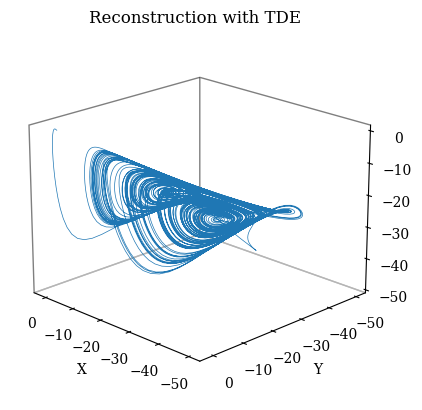

In [6]:
# Plot
ax = plt.figure().add_subplot(projection='3d')
s =  delay_embedding_matrix(xyzs[:,0],3*10)[:,::10]
ax.plot(*s.T, lw=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Reconstruction with TDE")

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.view_init(elev=20, azim=135)

ax.grid(False)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
    
plt.savefig('./../figure/tde_lorenz.png', format='png', dpi=200, bbox_inches='tight')
plt.show()

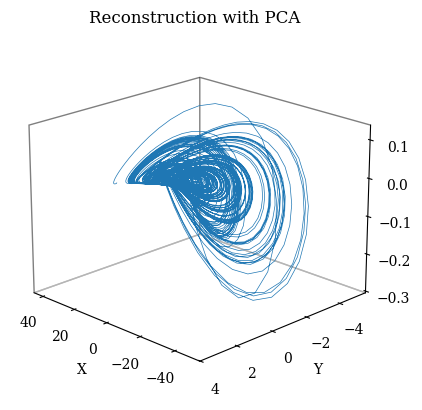

In [8]:
# Plot
ax = plt.figure().add_subplot(projection='3d')
s = PCA(n_components=3).fit_transform(delay_embedding_matrix(xyzs[::,0],3))
ax.plot(*s.T, lw=0.5)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Reconstruction with PCA")

ax.xaxis.set_rotate_label(False)
ax.yaxis.set_rotate_label(False)
ax.zaxis.set_rotate_label(False)
ax.view_init(elev=20, azim=135)

ax.grid(False)
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
plt.savefig('./../figure/pca_lorenz.png', format='png', dpi=200, bbox_inches='tight')

plt.show()

In [9]:
class MultilinearAE(nn.Module):

    def __init__(self, x_dims, rank, attractor_dim):
        super(MultilinearAE, self).__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim

        self.x_weights = nn.ParameterList([Parameter(torch.Tensor(dims, self.rank)) for dims in x_dims])
        self.attractor_weights = nn.ParameterList([Parameter(torch.Tensor(self.rank, self.attractor_dim))])
        self.x_weights_out = nn.ParameterList([Parameter(torch.Tensor(attractor_dim, dims)) for dims in x_dims])
        
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.attractor_weights]
        _ = [xavier_normal_(x_weight) for x_weight in self.x_weights_out]

    def encoder(self, Xs):
        hidden_Xs = [torch.matmul(Xs[i], x_weight) for i, x_weight in enumerate(self.x_weights)]
        hidden_X = 1
        for i in range(len(self.x_dims)):
            hidden_X *= hidden_Xs[i]
        S = torch.matmul(hidden_X, self.attractor_weights[0])
        return S
    def transform(self, Xs):
        Xs = [torch.from_numpy(X).to(torch.float) for X in Xs]
        return self.encoder(Xs).detach().cpu().numpy()
        
    def decoder(self, S):
        Xs_pred = [torch.matmul(S, x_weight) for i, x_weight in enumerate(self.x_weights_out)]
        return Xs_pred
        
    def forward(self, Xs):
         S = self.encoder(Xs)
         Xs_pred = self.decoder(S)
         return Xs_pred

In [10]:
def tensor_model_fit_transform(npa_Xs, attractor_dim):
    rank = 7
    x_dims = [x.shape[1] for x in npa_Xs] 
    model = MultilinearAE(x_dims, rank, attractor_dim)
    # model.cuda()

    optimizer = optim.Adam(model.parameters())
    epoch = 1000 
    loss_function = nn.MSELoss()
    ta_Xs = [torch.from_numpy(x).to(torch.float) for x in npa_Xs]
    for i in range(epoch):
        loss = 0
        optimizer.zero_grad()
        ta_Xs_rec = model(ta_Xs)
        for X, X_rec in zip(ta_Xs, ta_Xs_rec):
            loss += loss_function(X, X_rec)
        loss.backward()
        optimizer.step()
    model.eval()
    return model

In [11]:
def make_ts(person, activity):
    pdf_data_all = pd.read_csv(f'./../data/A_DeviceMotion_data/{activity}/sub_{person}.csv').reset_index(drop=True)
    data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    # data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z']
    data_list_short = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    # mean = pdf_data_all[data_list].mean()
    # var = pdf_data_all[data_list].var()**.5
    # pdf_data_all[data_list] = (pdf_data_all[data_list]-mean)/var
    pdf_data_all = pdf_data_all[data_list_short]
    xyz = pdf_data_all[data_list_short].to_numpy()
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    return x,y,z

In [12]:
from sklearn.decomposition import PCA, KernelPCA

In [16]:
def make_experiment_xy_z(activity, lag):
    result_tables_model_names = [
        'person',
        'X',
        'Kernel PCA',
        'Tensor X'
    ]
    pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
    pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
    for person in tqdm([1, 2, 4, 5, 6, 7, 8, 9, 11, 12]):
        
        x, _, _ = make_ts(person, activity)
        if x.shape[0] <= 650:
            continue
        X_tde = delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n]
    
        Xs_tde = [
            delay_embedding_matrix(x, lag, fit_intercept=True)[:,::freq_n],
            delay_embedding_matrix(x, lag, fit_intercept=True)[:,::freq_n]
        ]
        
        for dim_n in  range(3,11):
            _pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
            _pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
            # Make state space reconstruction models
            list_S = []
            list_model = [
                PCA(n_components=dim_n).fit( X_tde[:500,:]),
                KernelPCA(n_components=dim_n, kernel="poly").fit( X_tde[:500,:])
            ]
            
            list_S = [ model.transform(X_tde[:500,:]) for model in list_model ]
            
            model = tensor_model_fit_transform(Xs_tde, dim_n)
            list_S.append(model.transform([X[:500,:] for X in Xs_tde]))
            
            list_Wx_rec = [np.linalg.inv(S.T@S + l2_coef*np.identity(dim_n))@S.T@X_tde[:500,:] for S in list_S]
            
            # Make linear prediction models
            list_W_t_1 = [np.linalg.inv(S[:-25,:].T@S[:-25,:] + l2_coef*np.identity(dim_n))@S[:-25,:].T@S[25:,:] for S in list_S]
            
            # Dim reduction for valid ts
            list_S = [ model.transform(X_tde[500:-25,:]) for model in list_model]
            list_S.append(model.transform([X[500:-25,:] for X in Xs_tde]))
            # Make prediction on valid times series
            list_S_pred = [ s@w for s,w in zip(list_S, list_W_t_1)]
    
            # Resore initial time series
            x_rec = [diag_mean(s@w) for s,w in zip(list_S_pred, list_Wx_rec)]
            x_ts = diag_mean(X_tde[525:,:])
            
            _pdf_r2_train_ts.loc[dim_n, :] = [person]+[r2_score(x_ts, x) for x in x_rec]
            _pdf_mse_train_ts.loc[dim_n, :] = [person]+[mse(x_ts, x)**.5 for x in x_rec]

            pdf_r2_train_ts = pd.concat([pdf_r2_train_ts, _pdf_r2_train_ts], axis=0)
            pdf_mse_train_ts = pd.concat([pdf_mse_train_ts, _pdf_mse_train_ts], axis=0)

    return pdf_r2_train_ts, pdf_mse_train_ts

In [28]:
freq_n = 1
l2_coef = 1
list_all_exp = []
list_activities = [
    'dws_11',
    # 'ups_3', 'wlk_15',
    
    # 'dws_1', 'dws_2',
    # 'jog_16', 'jog_9',
    # 'sit_13', 'sit_5',
    # 'std_14', 'std_6',
    # 'ups_12', 'ups_4',
    'wlk_7',
    # 'wlk_8'.
]

list_all_exp = [make_experiment_xy_z(activity, 50) for activity in list_activities]

100%|██████████| 10/10 [02:49<00:00, 16.98s/it]


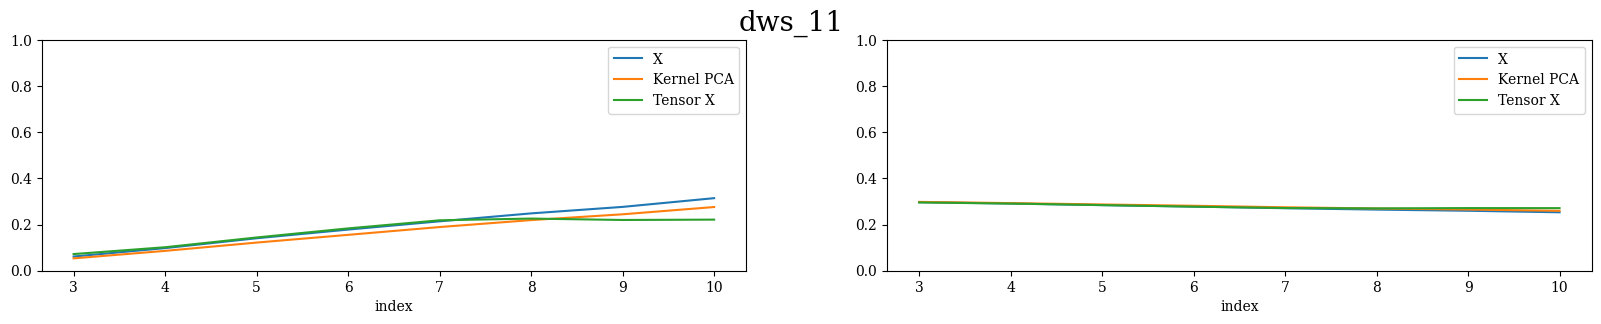

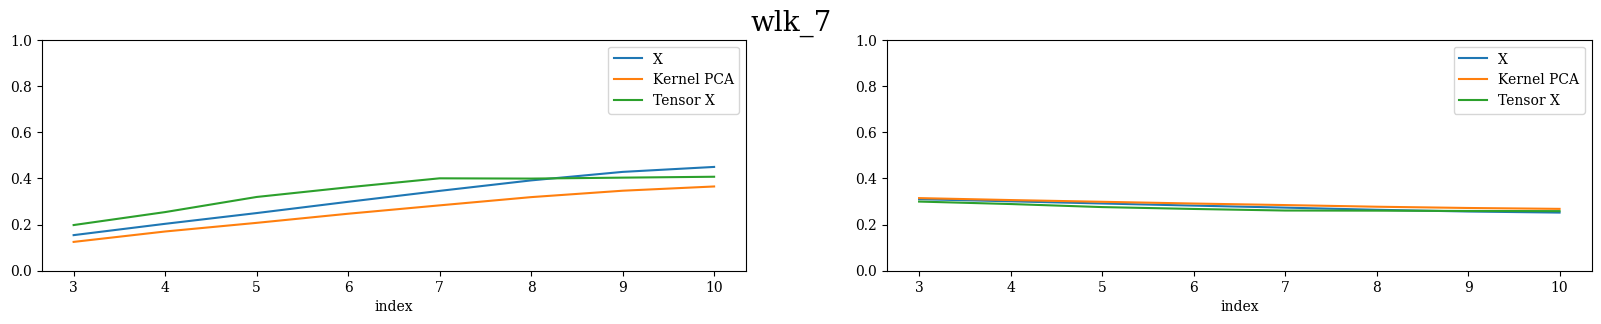

In [29]:
for name, exp_act in zip(list_activities, list_all_exp):
    fig, axs = plt.subplots(1,2,figsize=(20,3))
    _ = [DF.drop(columns=['person']).reset_index().groupby('index').mean().plot(ax=ax) for DF, ax in zip(exp_act, axs)]
    _ = [ax.set_ylim(0,1) for ax in axs]
    fig.suptitle(name, fontsize=20)

In [32]:
exp_act = list_all_exp[0]
df_r2x, df_msex = [DF.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3) for DF in exp_act]
print(' \n'.join(["{} & {} & {} & {} & {} & {} & {} \\\\".format(d,r[0],m[0],r[1],m[1],r[2],m[2])  for d, r, m in zip(df_r2x.index, df_r2x.values, df_msex.values)]))
print()

3 & 0.061 & 0.297 & 0.053 & 0.298 & 0.072 & 0.296 \\ 
4 & 0.098 & 0.291 & 0.086 & 0.293 & 0.102 & 0.291 \\ 
5 & 0.141 & 0.284 & 0.122 & 0.287 & 0.144 & 0.284 \\ 
6 & 0.178 & 0.278 & 0.155 & 0.281 & 0.183 & 0.278 \\ 
7 & 0.214 & 0.271 & 0.189 & 0.275 & 0.218 & 0.271 \\ 
8 & 0.248 & 0.265 & 0.219 & 0.269 & 0.226 & 0.27 \\ 
9 & 0.276 & 0.26 & 0.244 & 0.265 & 0.22 & 0.271 \\ 
10 & 0.314 & 0.253 & 0.276 & 0.259 & 0.221 & 0.271 \\



In [33]:
exp_act = list_all_exp[1]
df_r2x, df_msex = [DF.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3) for DF in exp_act]
print(' \n'.join(["{} & {} & {} & {} & {} & {} & {} \\\\".format(d,r[0],m[0],r[1],m[1],r[2],m[2])  for d, r, m in zip(df_r2x.index, df_r2x.values, df_msex.values)]))
print()

3 & 0.154 & 0.31 & 0.125 & 0.314 & 0.198 & 0.299 \\ 
4 & 0.203 & 0.301 & 0.17 & 0.306 & 0.254 & 0.289 \\ 
5 & 0.25 & 0.291 & 0.207 & 0.298 & 0.319 & 0.276 \\ 
6 & 0.298 & 0.282 & 0.247 & 0.291 & 0.361 & 0.267 \\ 
7 & 0.346 & 0.273 & 0.283 & 0.284 & 0.4 & 0.261 \\ 
8 & 0.391 & 0.264 & 0.319 & 0.277 & 0.399 & 0.26 \\ 
9 & 0.428 & 0.256 & 0.346 & 0.272 & 0.403 & 0.259 \\ 
10 & 0.449 & 0.252 & 0.365 & 0.268 & 0.407 & 0.258 \\

